## SETUP


In [1]:
import matplotlib.pyplot as plt
import pandas as pd


def load_data(p): return pd.read_csv(p)
def ber_stats(df):
    compiled=df[df['ber']!='-']
    ber1=(compiled['ber']=='1.0').sum()
    return ber1,len(compiled)


### Load result to data frame


In [2]:
single=load_data('../single/result.csv'); multi=load_data('../multi/result.csv')


# RAW BER -- All Entries


#### Overall BER


BER conditional on CSR pass (among compiled entries):
  Single: 21/189 = 11.1%
  Multi: 16/163 = 9.8%


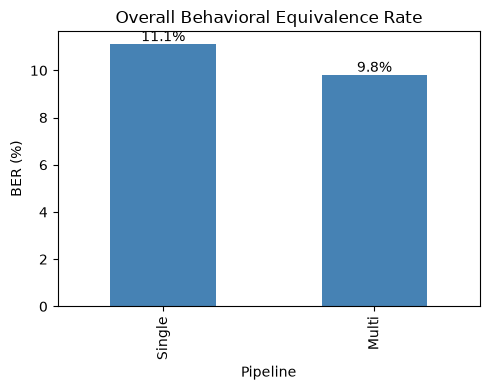


BER unconditional (- counted as fail):
  Single: 21/279 = 7.5%
  Multi: 16/279 = 5.7%


In [3]:
print('BER conditional on CSR pass (among compiled entries):')
rows=[]
for label,df in [('Single',single),('Multi',multi)]:
    ok,tot=ber_stats(df)
    pct=ok/tot*100 if tot else 0
    print(f'  {label}: {ok}/{tot} = {pct:.1f}%')
    rows.append({'Pipeline':label,'BER (%)':round(pct,1)})
ber_ov=pd.DataFrame(rows).set_index('Pipeline')
ax=ber_ov.plot.bar(figsize=(5,4),legend=False,color=['steelblue','coral'])
ax.set_ylabel('BER (%)'); ax.set_title('Overall Behavioral Equivalence Rate')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom')
plt.tight_layout(); plt.savefig('../charts/ber/ber_overall_raw.png', dpi=100, bbox_inches='tight')
plt.show()
print()
print('BER unconditional (- counted as fail):')
for label,df in [('Single',single),('Multi',multi)]:
    ber1=(df['ber']=='1.0').sum()
    print(f'  {label}: {ber1}/{len(df)} = {ber1/len(df)*100:.1f}%')


#### Per-Intent BER


                         Single  Multi
intent                                
CONSOLIDATE_CONDITIONAL     0.0    4.5
DECOMPOSE_CONDITIONAL      13.5    4.5
EXTRACT_CONSTANT           25.0   33.3
EXTRACT_METHOD             17.6   11.5
EXTRACT_VARIABLE            0.0    0.0
FLATTEN_CONDITIONAL        16.7   10.0
INLINE_METHOD              14.3   13.3
INLINE_VARIABLE             7.1    0.0
REMOVE_CONTROL_FLAG         0.0    0.0
RENAME_SYMBOL              10.3   22.2
SPLIT_LOOP                  6.2    0.0


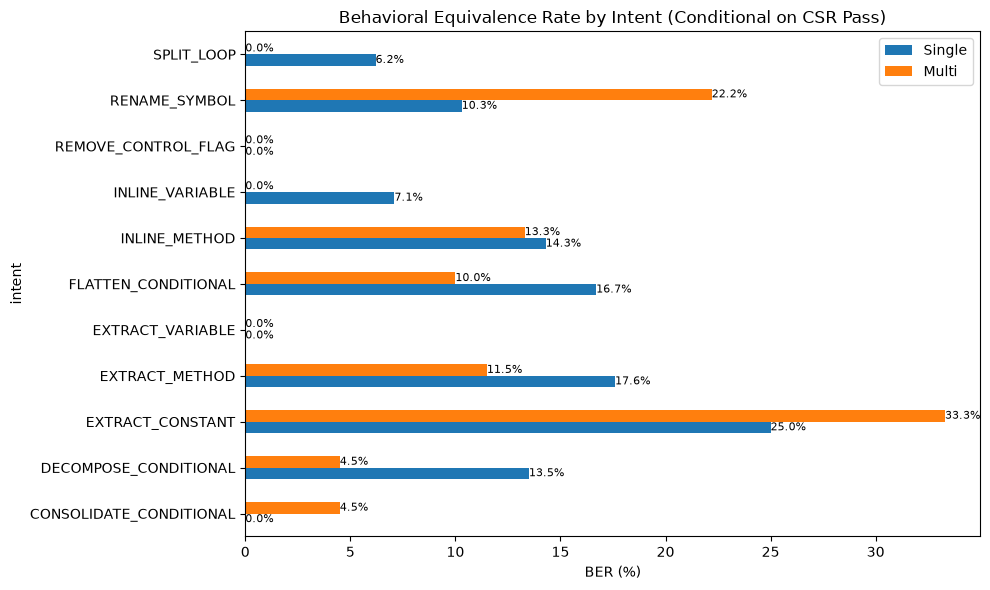

In [4]:
def intent_ber(df):
    ok=df[df['ber']=='1.0'].groupby('intent').size()
    compiled=df[df['ber']!='-'].groupby('intent').size()
    return (ok/compiled*100).round(1).fillna(0)
ber_intent=pd.DataFrame({'Single':intent_ber(single),'Multi':intent_ber(multi)})
print(ber_intent)
ax=ber_intent.plot.barh(figsize=(10,6))
ax.set_title('Behavioral Equivalence Rate by Intent (Conditional on CSR Pass)')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',(p.get_width(),p.get_y()+p.get_height()/2),ha='left',va='center',fontsize=8)
ax.set_xlabel('BER (%)'); plt.tight_layout(); plt.savefig('../charts/ber/ber_per_intent_raw.png', dpi=100, bbox_inches='tight')
plt.show()


#### BER by Difficulty


            Single  Multi
difficulty               
Easy          3.92   4.65
Hard         13.51   7.14
Medium       13.86  13.04


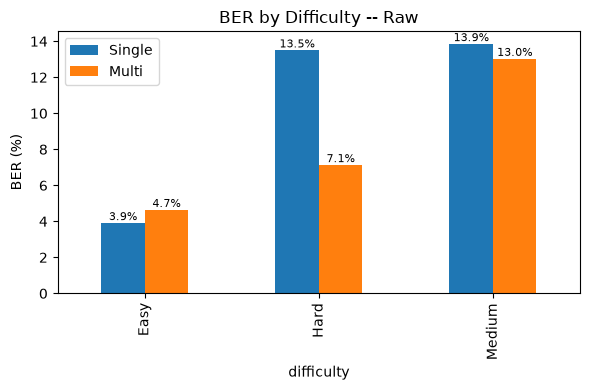

In [5]:
def diff_ber(df):
    ok=df[df['ber']=='1.0'].groupby('difficulty').size()
    compiled=df[df['ber']!='-'].groupby('difficulty').size()
    return (ok/compiled*100).round(2).fillna(0)
ber_diff=pd.DataFrame({'Single':diff_ber(single),'Multi':diff_ber(multi)})
print(ber_diff)
ax=ber_diff.plot.bar(figsize=(6,4))
ax.set_title('BER by Difficulty -- Raw'); ax.set_ylabel('BER (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.savefig('../charts/ber/ber_diff_raw.png', dpi=100, bbox_inches='tight')
plt.show()


# BER -- SUCCESS Exit Only


#### Overall BER (SUCCESS Only)


BER conditional on CSR pass:
  Single: 21/182 = 11.5%


  Multi: 13/119 = 10.9%


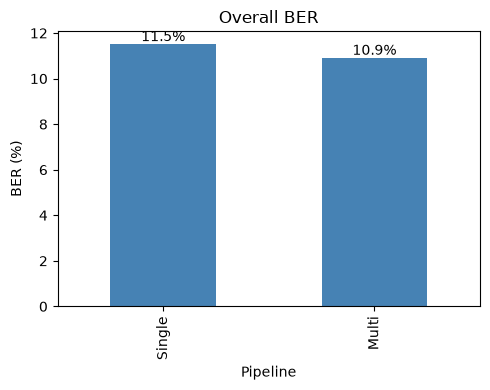

In [6]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
print('BER conditional on CSR pass:')
rows=[]
for label,df in [('Single',s_valid),('Multi',m_valid)]:
    ok,tot=ber_stats(df)
    if tot:
        print(f'  {label}: {ok}/{tot} = {ok/tot*100:.1f}%')
        rows.append({'Pipeline':label,'BER (%)':round(ok/tot*100,1)})
ber_ov_succ=pd.DataFrame(rows).set_index('Pipeline')
ax=ber_ov_succ.plot.bar(figsize=(5,4),legend=False,color=['steelblue','coral'])
ax.set_ylabel('BER (%)'); ax.set_title('Overall BER')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom')
plt.tight_layout(); plt.savefig('../charts/ber/ber_overall_success.png', dpi=100, bbox_inches='tight')
plt.show()


#### Per-Intent BER (SUCCESS Only)


                         Single  Multi
intent                                
CONSOLIDATE_CONDITIONAL     0.0    0.0
DECOMPOSE_CONDITIONAL      13.5    4.5
EXTRACT_CONSTANT           28.6   40.0
EXTRACT_METHOD             17.6   11.5
EXTRACT_VARIABLE            0.0    0.0
FLATTEN_CONDITIONAL        16.7   16.7
INLINE_METHOD              14.3   10.0
INLINE_VARIABLE             8.3    0.0
REMOVE_CONTROL_FLAG         0.0    0.0
RENAME_SYMBOL              10.3   20.8
SPLIT_LOOP                  6.2    0.0


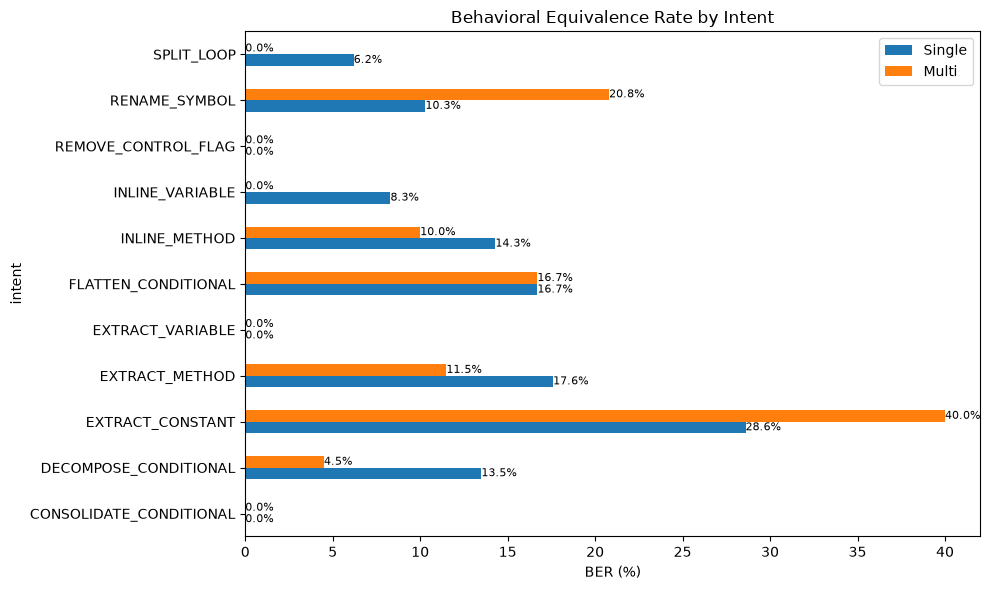

In [7]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
ber_succ=pd.DataFrame({'Single':intent_ber(s_valid),'Multi':intent_ber(m_valid)})
print(ber_succ)
ax=ber_succ.plot.barh(figsize=(10,6))
ax.set_title('Behavioral Equivalence Rate by Intent')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',(p.get_width(),p.get_y()+p.get_height()/2),ha='left',va='center',fontsize=8)
ax.set_xlabel('BER (%)'); plt.tight_layout(); plt.savefig('../charts/ber/ber_per_intent_success.png', dpi=100, bbox_inches='tight')
plt.show()


#### BER by Difficulty (SUCCESS Only)


            Single  Multi
difficulty               
Easy          4.08   5.71
Hard         14.71   8.70
Medium       14.14  14.75


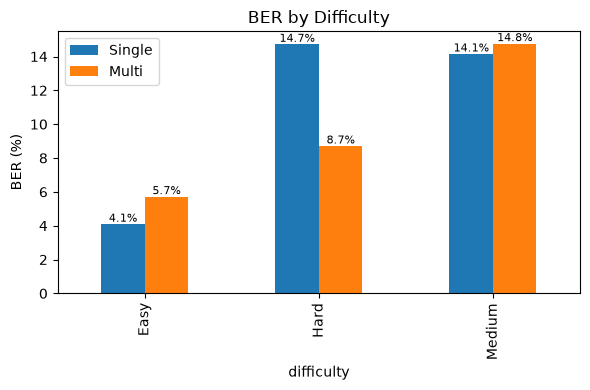

In [8]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
ber_diff_succ=pd.DataFrame({'Single':diff_ber(s_valid),'Multi':diff_ber(m_valid)})
print(ber_diff_succ)
ax=ber_diff_succ.plot.bar(figsize=(6,4))
ax.set_title('BER by Difficulty'); ax.set_ylabel('BER (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.savefig('../charts/ber/ber_diff_success.png', dpi=100, bbox_inches='tight')
plt.show()
